## 1. Cargar de datos

In [171]:
import pandas as pd
import requests

url = 'https://raw.githubusercontent.com/ver0nica1/challenge2-data-science/main/TelecomX_Data.json'

response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


### Normalizando los datos

In [172]:
df = pd.json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## 2. Transformación

✅ Explorar las columnas del dataset y verificar sus tipos de datos.

✅ Consultar el diccionario para comprender mejor el significado de las variables.

✅ Identificar las columnas más relevantes para el análisis de evasión.

In [173]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer.gender            7267 non-null   str    
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   str    
 5   customer.Dependents        7267 non-null   str    
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   str    
 8   phone.MultipleLines        7267 non-null   str    
 9   internet.InternetService   7267 non-null   str    
 10  internet.OnlineSecurity    7267 non-null   str    
 11  internet.OnlineBackup      7267 non-null   str    
 12  internet.DeviceProtection  7267 non-null   str    
 13  internet.TechSupport       7267 non-null   str    
 14  int

In [174]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
categorical_cols

Index(['customerID', 'Churn', 'customer.gender', 'customer.Partner',
       'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines',
       'internet.InternetService', 'internet.OnlineSecurity',
       'internet.OnlineBackup', 'internet.DeviceProtection',
       'internet.TechSupport', 'internet.StreamingTV',
       'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Total'],
      dtype='str')

### Verificación de valores únicos

In [175]:
for col in categorical_cols:
  print(f'valores de {col}: {df[col].unique()}')

valores de customerID: <StringArray>
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ',
 '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS',
 ...
 '9975-SKRNR', '9978-HYCIN', '9979-RGMZT', '9985-MWVIX', '9986-BONCE',
 '9987-LUTYD', '9992-RRAMN', '9992-UJOEL', '9993-LHIEB', '9995-HOTOH']
Length: 7267, dtype: str
valores de Churn: <StringArray>
['No', 'Yes', '']
Length: 3, dtype: str
valores de customer.gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
valores de customer.Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
valores de customer.Dependents: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
valores de phone.PhoneService: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
valores de phone.MultipleLines: <StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str
valores de internet.InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
valores de internet.OnlineSecurity: <StringArray

### Verificación de valores duplicados

In [176]:
print("Numeros duplicados:", df.duplicated().sum())

Numeros duplicados: 0


### Verificación de valores nulos

In [177]:
print("Valores nulos:\n", df.isnull().sum())

Valores nulos:
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


### Verificación de valores vacios o en blanco

In [178]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

customerID                     0
Churn                        224
customer.gender                0
customer.SeniorCitizen         0
customer.Partner               0
customer.Dependents            0
customer.tenure                0
phone.PhoneService             0
phone.MultipleLines            0
internet.InternetService       0
internet.OnlineSecurity        0
internet.OnlineBackup          0
internet.DeviceProtection      0
internet.TechSupport           0
internet.StreamingTV           0
internet.StreamingMovies       0
account.Contract               0
account.PaperlessBilling       0
account.PaymentMethod          0
account.Charges.Monthly        0
account.Charges.Total         11
dtype: int64

### Cambiando la columna account.Charges.Total a tipo float

In [179]:
df['account.Charges.Total'] = df['account.Charges.Total'].apply(pd.to_numeric, errors='coerce')
print(df['account.Charges.Total'].dtype)

float64


### Eliminación de valores vacios en la columna Churn

In [180]:
df = df[df['Churn'].str.strip() != '']
print("Número de filas después de eliminar los vacios en Churn:", len(df))

Número de filas después de eliminar los vacios en Churn: 7043


In [181]:
df.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   str    
 1   Churn                      7043 non-null   str    
 2   customer.gender            7043 non-null   str    
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   str    
 5   customer.Dependents        7043 non-null   str    
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   str    
 8   phone.MultipleLines        7043 non-null   str    
 9   internet.InternetService   7043 non-null   str    
 10  internet.OnlineSecurity    7043 non-null   str    
 11  internet.OnlineBackup      7043 non-null   str    
 12  internet.DeviceProtection  7043 non-null   str    
 13  internet.TechSupport       7043 non-null   str    
 14  internet

In [182]:
print("Valores nulos:\n", df.isnull().sum())

Valores nulos:
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


### Eliminar valores nulos

In [183]:
df = df.dropna(subset=['account.Charges.Total'])
print("Valores nulos:\n", df.isnull().sum())

Valores nulos:
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


### Renombrar columnas

In [184]:
df.columns.to_list()

['customerID',
 'Churn',
 'customer.gender',
 'customer.SeniorCitizen',
 'customer.Partner',
 'customer.Dependents',
 'customer.tenure',
 'phone.PhoneService',
 'phone.MultipleLines',
 'internet.InternetService',
 'internet.OnlineSecurity',
 'internet.OnlineBackup',
 'internet.DeviceProtection',
 'internet.TechSupport',
 'internet.StreamingTV',
 'internet.StreamingMovies',
 'account.Contract',
 'account.PaperlessBilling',
 'account.PaymentMethod',
 'account.Charges.Monthly',
 'account.Charges.Total']

In [185]:
columnas_nuevas = [
    'ID_Cliente',
    'Desercion',
    'Genero',
    'Adulto_Mayor',
    'Pareja',
    'Dependientes',
    'Antiguedad_Meses',
    'Servicio_Telefonico',
    'Multiples_Lineas',
    'Servicio_Internet',
    'Seguridad_Online',
    'Respaldo_online',
    'Proteccion_Dispositivo',
    'Soporte_Tecnico',
    'Servicio_StreamingTV',
    'Peliculas_Streaming',
    'Tipo_Contrato',
    'Factura_Online',
    'Metodo_Pago',
    'Cargo_Mensual',
    'Cargo_Total'

]

from typing import Mapping
Mapping = dict(zip(df.columns, columnas_nuevas))
df = df.rename(columns=Mapping)
df.head()

,ID_Cliente,Desercion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Respaldo_online,Proteccion_Dispositivo,Soporte_Tecnico,Servicio_StreamingTV,Peliculas_Streaming,Tipo_Contrato,Factura_Online,Metodo_Pago,Cargo_Mensual,Cargo_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


### Crear nueva columna "Cuentas diarías"

In [186]:
df['Cuentas_Diarias'] = df['Cargo_Mensual'] / 30
df.head()

,ID_Cliente,Desercion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Servicio_StreamingTV,Peliculas_Streaming,Tipo_Contrato,Factura_Online,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


### Renombrar datos de columnas y datos binarios

In [187]:
traducir_columnas = ['Seguridad_Online', 'Respaldo_online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Servicio_StreamingTV', 'Peliculas_Streaming',]
mapeo = {'No': 0, 'Yes': 1, 'No internet service': 0}

for col in traducir_columnas:
  df[col] = df[col].replace(mapeo)
df.head()

,ID_Cliente,Desercion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Servicio_StreamingTV,Peliculas_Streaming,Tipo_Contrato,Factura_Online,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,0,1,1,0,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,0,0,0,1,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,1,0,0,0,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,1,0,1,1,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,0,1,1,0,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [188]:
df['Desercion'] = df['Desercion'].replace({'No': 0, 'Yes': 1})
df['Genero'] = df['Genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})
df['Pareja'] = df['Pareja'].replace({'No': 0, 'Yes': 1})
df['Dependientes'] = df['Dependientes'].replace({'No': 0, 'Yes': 1})
df['Servicio_Telefonico'] = df['Servicio_Telefonico'].replace({'No': 0, 'Yes': 1})
df['Tipo_Contrato'] = df['Tipo_Contrato'].replace({'Month-to-month': 'Mensual', 'Two year': 'Dos años', 'One year': 'Un año'})
df['Factura_Online'] = df['Factura_Online'].replace({'No': 0, 'Yes': 1})
df['Metodo_Pago'] = df['Metodo_Pago'].replace({'Electronic check': 'Cheque Electrónico', 'Mailed check': 'Cheque por correo', 'Bank transfer (automatic)': 'Transferencia bancaria', 'Credit card (automatic)': 'Tarjeta de crédito'})
df['Multiples_Lineas'] = df['Multiples_Lineas'].replace({'No': 0, 'Yes': 1, 'No phone service': 0})
df.head()

,ID_Cliente,Desercion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Servicio_StreamingTV,Peliculas_Streaming,Tipo_Contrato,Factura_Online,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,Femenino,0,1,1,9,1,0,DSL,...,0,1,1,0,Un año,1,Cheque por correo,65.6,593.30,2.186667
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensual,0,Cheque por correo,59.9,542.40,1.996667
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Mensual,1,Cheque Electrónico,73.9,280.85,2.463333
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Mensual,1,Cheque Electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Mensual,1,Cheque por correo,83.9,267.40,2.796667


In [189]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7032 non-null   str    
 1   Desercion               7032 non-null   object 
 2   Genero                  7032 non-null   str    
 3   Adulto_Mayor            7032 non-null   int64  
 4   Pareja                  7032 non-null   object 
 5   Dependientes            7032 non-null   object 
 6   Antiguedad_Meses        7032 non-null   int64  
 7   Servicio_Telefonico     7032 non-null   object 
 8   Multiples_Lineas        7032 non-null   object 
 9   Servicio_Internet       7032 non-null   str    
 10  Seguridad_Online        7032 non-null   object 
 11  Respaldo_online         7032 non-null   object 
 12  Proteccion_Dispositivo  7032 non-null   object 
 13  Soporte_Tecnico         7032 non-null   object 
 14  Servicio_StreamingTV    7032 non-null   object 
 15  Pel

## 3. Carga y análisis

In [190]:
df.describe()

,Adulto_Mayor,Antiguedad_Meses,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


### Distribución de la evasión

In [191]:
colores = ['#590D22', '#800F2F', '#A4133C', '#C9184A', '#FF4D6D', '#FF758F', '#FF8FA3', '#FFB3C1']

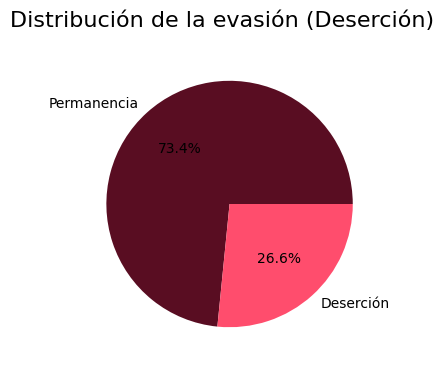

In [192]:
import matplotlib.pyplot as plt
import seaborn as sns

total_desercion = df['Desercion'].value_counts().sort_index()

etiquetas = ['Permanencia', 'Deserción']
fig, ax = plt.subplots(figsize=(6,4))
fig.suptitle('Distribución de la evasión (Deserción)', fontsize=16)
ax.pie(total_desercion.values, labels=etiquetas, autopct='%1.1f%%', colors=[colores[0], colores[4]])
plt.show()

In [193]:
desercion_por_genero =  df['Genero'].value_counts()
porcentaje_por_genero = df['Genero'].value_counts(normalize=True) * 100

resumen_genero = pd.DataFrame({'Desercion': desercion_por_genero, 'Porcentaje': porcentaje_por_genero})
resumen_genero['Desercion'] = resumen_genero['Desercion'].apply(lambda x: f'{x:,.0f}')
resumen_genero['Porcentaje'] = resumen_genero['Porcentaje'].apply(lambda x: f'{x:.2f}%')
resumen_genero

,Desercion,Porcentaje
Genero,,
Masculino,"3,549",50.47%
Femenino,"3,483",49.53%


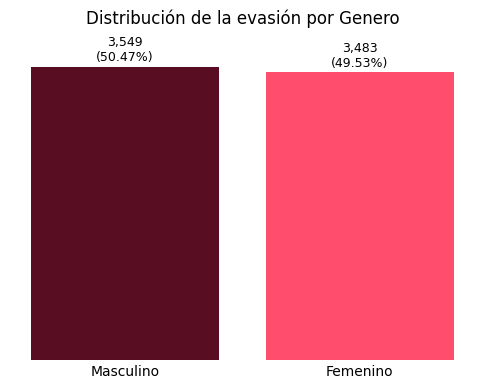

In [194]:
desercion_por_genero =  df['Genero'].value_counts()
porcentaje_por_genero = df['Genero'].value_counts(normalize=True) * 100

colores_distribucion=[colores[0], colores[4]] #Agregan colores
fig, ax = plt.subplots(figsize=(6,4)) #crea el gráfico
ax.set_frame_on(False) #Oculta el marco
ax.tick_params(axis='x', which='both', size=0) # quitan los ticks del eje x
ax.bar(desercion_por_genero.index, desercion_por_genero.values, color=colores_distribucion) #seleccionan las barras

ax.set_title('Distribución de la evasión por Genero', pad=20)
ax.set_yticks([]) # quitan las etiquetas del eje y

#Añadir etiquetas númericas
for i, (total, porcentaje) in enumerate(zip(desercion_por_genero.values, porcentaje_por_genero.values)):
  ax.text(i, total +30,
          f'{total:,.0f}\n({porcentaje:.2f}%)',
          fontsize=9, ha='center', va='bottom', color='black')

plt.show()

### Relación entre la deserción y la antiguedad

In [205]:
import plotly.express as px
import pandas as pd

# Creamos categorías por: 'Antiguedad_Meses'
bins = [0, 12, 36, 60, df['Antiguedad_Meses'].max() + 1]
labels = ['0-12 meses', '13-36 meses', '37-60 meses', '61+ meses']
df['Antiguedad_Categoria'] = pd.cut(df['Antiguedad_Meses'], bins=bins, labels=labels, right=False)

# Crear una columna con etiquetas descriptivas para 'Desercion' para el gráfico
df_plot = df.copy()
df_plot['Desercion'] = df_plot['Desercion'].map({0: 'No Deserta', 1: 'Deserta'})

px.histogram(df_plot, x='Antiguedad_Meses', color='Desercion', text_auto=True,
             color_discrete_map={'No Deserta': colores[0], 'Deserta': colores[4]},
             barmode='group',
             title='Relación entre la deserción y la antiguedad',
             labels={'Antiguedad_Meses': 'Antigüedad (Meses)', 'count': 'Número de Clientes'})

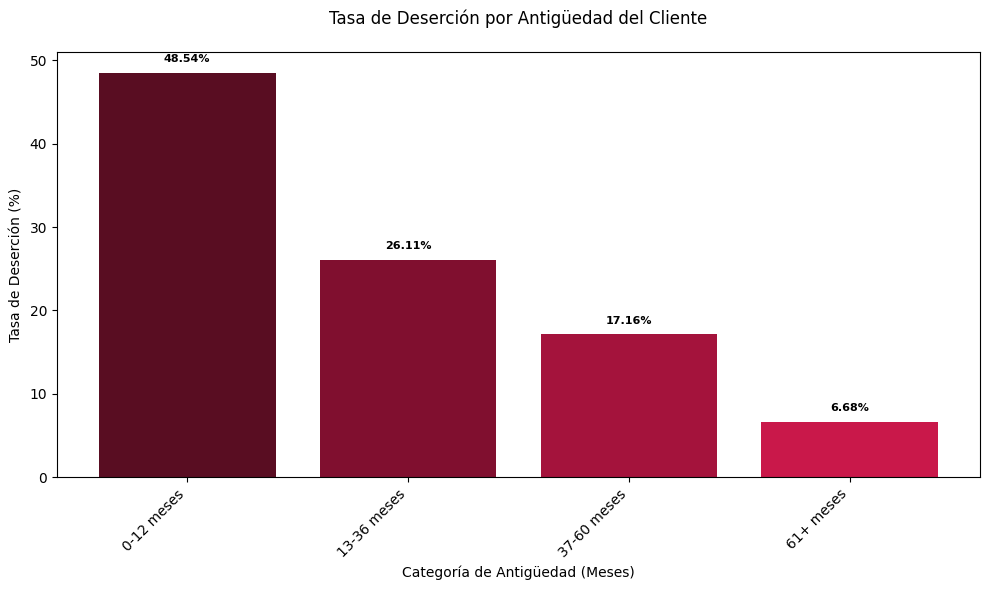

In [207]:
# Calcular la tasa de deserción por Antiguedad_Categoria
desercion_por_antiguedad = df.groupby('Antiguedad_Categoria', observed=False)['Desercion'].value_counts(normalize=True).unstack()
desercion_por_antiguedad['Churn_Rate'] = desercion_por_antiguedad[1] * 100 # Churn_Rate para 'Yes'

# Crear el gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(desercion_por_antiguedad.index, desercion_por_antiguedad['Churn_Rate'], color=colores)

ax.set_title('Tasa de Deserción por Antigüedad del Cliente', pad=20)
ax.set_xlabel('Categoría de Antigüedad (Meses)')
ax.set_ylabel('Tasa de Deserción (%)')

# Añadir etiquetas de porcentaje en las barras
for i, rate in enumerate(desercion_por_antiguedad['Churn_Rate']):
    ax.text(i, rate + 1, f'{rate:.2f}%', ha='center', va='bottom', fontsize=8, color='black', weight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### identificamos que hay mayor deserción de clientes en el primer año

### Deserción por tipo de contrato

In [208]:
desercion_por_contrato = df.groupby('Tipo_Contrato')['Desercion'].value_counts(normalize=True).unstack()
desercion_por_contrato['Churn_Rate'] = desercion_por_contrato[1] * 100

print("Tasa de Deserción por Tipo de Contrato:")
print(desercion_por_contrato)

Tasa de Deserción por Tipo de Contrato:
Desercion             0         1  Churn_Rate
Tipo_Contrato                                
Dos años       0.971513  0.028487    2.848665
Mensual        0.572903  0.427097   42.709677
Un año         0.887228  0.112772   11.277174


In [210]:
# Asegurarse de que df_plot tenga la columna 'Desercion' mapeada para el gráfico
df_plot = df.copy()
df_plot['Desercion'] = df_plot['Desercion'].map({0: 'No Deserta', 1: 'Deserta'})

# Crear el histograma con Plotly Express
fig = px.histogram(df_plot, x='Tipo_Contrato', color='Desercion', barmode='group',
                   color_discrete_map={'No Deserta': colores[3], 'Deserta': colores[5]},
                   title='Distribución de la Deserción por Tipo de Contrato',
                   labels={'Tipo_Contrato': 'Tipo de Contrato', 'count': 'Número de Clientes'})

fig.update_layout(xaxis_title='Tipo de Contrato', yaxis_title='Número de Clientes')
fig.show()

#### los clientes con mayor deserción son los que cuentan con un contrato mensual

### Deserción por tipo de servicio

In [211]:
desercion_por_servicio_internet = df.groupby('Servicio_Internet')['Desercion'].value_counts(normalize=True).unstack()
desercion_por_servicio_internet['Churn_Rate'] = desercion_por_servicio_internet[1] * 100

print("Tasa de Deserción por Servicio de Internet:")
print(desercion_por_servicio_internet)

Tasa de Deserción por Servicio de Internet:
Desercion                 0         1  Churn_Rate
Servicio_Internet                                
DSL                0.810017  0.189983   18.998344
Fiber optic        0.581072  0.418928   41.892765
No                 0.925658  0.074342    7.434211


In [222]:
# Asegurarse de que df_plot tenga la columna 'Desercion' mapeada para el gráfico
df_plot = df.copy()
df_plot['Desercion'] = df_plot['Desercion'].map({0: 'No Deserta', 1: 'Deserta'})

# Crear el histograma con Plotly Express
fig = px.histogram(df_plot, x='Servicio_Internet', color='Desercion', barmode='group',
                   color_discrete_map={'No Deserta': colores[2], 'Deserta': colores[6]},
                   title='Distribución de la Deserción por Servicio de Internet',
                   labels={'Servicio_Internet': 'Tipo de Servicio de Internet', 'count': 'Número de Clientes'})

fig.update_layout(xaxis_title='Tipo de Servicio de Internet', yaxis_title='Número de Clientes')
fig.show()

### Deserción por método de pago

In [227]:
# Asegurarse de que df_plot tenga la columna 'Desercion' mapeada para el gráfico
df_plot = df.copy()
df_plot['Desercion'] = df_plot['Desercion'].map({0: 'No Deserta', 1: 'Deserta'})

# Crear el histograma con Plotly Express
fig = px.histogram(df_plot, x='Metodo_Pago', color='Desercion', barmode='group',
                   color_discrete_map={'No Deserta': colores[3], 'Deserta': colores[5]},
                   title='Distribución de la Deserción por Método de Pago',
                   labels={'Metodo_Pago': 'Método de Pago', 'count': 'Número de Clientes'})

fig.update_layout(xaxis_title='Método de Pago', yaxis_title='Número de Clientes')
fig.show()

#### El metodo de pago con mayor deserción es el cheque electronico

### Conteo de evsión por variables númericas

In [228]:
df['Tiene_Servicio_Internet'] = df['Servicio_Internet'].apply(lambda x: 1 if x in ['DSL', 'Fiber optic'] else 0)
df[['Servicio_Internet', 'Tiene_Servicio_Internet']].head()

,Servicio_Internet,Tiene_Servicio_Internet
0,DSL,1
1,DSL,1
2,Fiber optic,1
3,Fiber optic,1
4,Fiber optic,1


In [230]:
servicios_relevantes = [
    'Servicio_Telefonico',
    'Multiples_Lineas',
    'Tiene_Servicio_Internet',
    'Seguridad_Online',
    'Respaldo_online',
    'Proteccion_Dispositivo',
    'Soporte_Tecnico',
    'Servicio_StreamingTV',
    'Peliculas_Streaming'
]

# Crear un DataFrame vacío para almacenar las proporciones
df_radar = pd.DataFrame(index=[0, 1])

for col in servicios_relevantes:
    # Calcular la proporción de clientes para cada servicio, separado por deserción
    proporcion_servicio = df.groupby('Desercion')[col].value_counts(normalize=True).unstack()

    # Extraer la proporción de clientes que tienen el servicio (valor 1) para ambos casos de Desercion
    # Si no hay valor para 1, se asume 0
    prop_no_deserta = proporcion_servicio.get(1, pd.Series({0: 0.0}))[0] if 0 in proporcion_servicio.index else 0.0
    prop_deserta = proporcion_servicio.get(1, pd.Series({1: 0.0}))[1] if 1 in proporcion_servicio.index else 0.0

    df_radar[col] = [prop_no_deserta, prop_deserta]

df_radar.index.name = 'Desercion'
df_radar

,Servicio_Telefonico,Multiples_Lineas,Tiene_Servicio_Internet,Seguridad_Online,Respaldo_online,Proteccion_Dispositivo,Soporte_Tecnico,Servicio_StreamingTV,Peliculas_Streaming
Desercion,,,,,,,,,
0,0.901220,0.410033,0.727484,0.333140,0.368390,0.362774,0.335077,0.365873,0.370521
1,0.909042,0.454789,0.939540,0.157838,0.279829,0.291600,0.165864,0.435527,0.437667


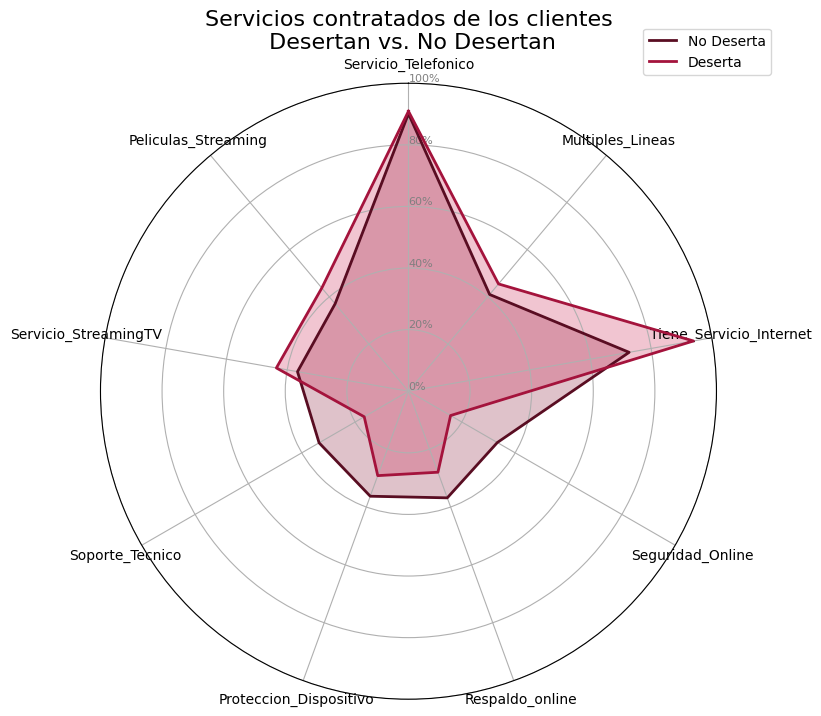

In [245]:
colores = ['#590D22', '#800F2F', '#A4133C', '#C9184A', '#FF4D6D', '#FF758F', '#FF8FA3', '#FFB3C1']

#Extrae las categorías (nombres de los servicios) de las columnas de df_radar y la cantidad de categorías.
categories = list(df_radar.columns)
num_vars = len(categories)

# Añade la primera categoría al final de la lista de categorías para cerrar el gráfico de araña.
categories = categories + categories[:1]

# Extrae los valores de las proporciones para los clientes que no desertan (índice 0) y para los clientes que desertan (índice 1) de df_radar.
# Añade el primer valor de cada serie al final para cerrar las líneas del gráfico.
values_no_churn = df_radar.loc[0].tolist()
values_no_churn = values_no_churn + values_no_churn[:1]

values_churn = df_radar.loc[1].tolist()
values_churn = values_churn + values_churn[:1]

# Define los ángulos para cada eje del gráfico de araña utilizando np.linspace.
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles = angles + angles[:1] # Para cerrar el círculo

# Crea una figura y un subplot con proyección 'polar'.
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(polar=True))

# Dibuja las líneas del gráfico de araña para los clientes que no desertan y para los que desertan
ax.plot(angles, values_no_churn, color=colores[0], linewidth=2, label='No Deserta')
ax.fill(angles, values_no_churn, color=colores[1], alpha=0.25)

ax.plot(angles, values_churn, color=colores[2], linewidth=2, label='Deserta')
ax.fill(angles, values_churn, color=colores[3], alpha=0.25)

# 8. Configura los ticks de los ejes polares y las etiquetas de las categorías.
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rlabel_position(0) # Posición de las etiquetas radiales

# Establece los ticks y etiquetas para las categorías
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories[:-1])

# Configura los ticks radiales
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], color="grey", size=8)
ax.set_ylim(0, 1) # Establece el límite del eje radial de 0 a 1 (proporción)

# 9. Añade una leyenda al gráfico.
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

# 10. Añade un título al gráfico.
ax.set_title('Servicios contratados de los clientes\n Desertan vs. No Desertan', pad=25, fontsize=16)

# 11. Muestra el gráfico.
plt.show()

### Relación entre el gasto del cliente y la deserción

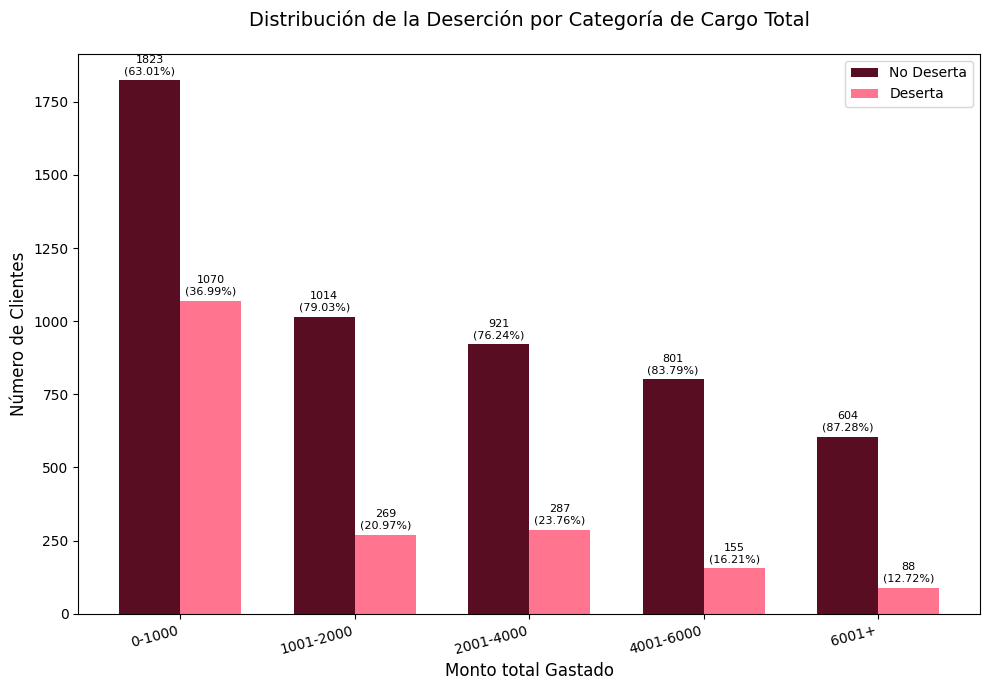

In [248]:
# Crear categorías para 'Cargo_Total'
bins = [0, 1000, 2000, 4000, 6000, df['Cargo_Total'].max() + 1]
labels = ['0-1000', '1001-2000', '2001-4000', '4001-6000', '6001+']
df['Cargo_Total_Categoria'] = pd.cut(df['Cargo_Total'], bins=bins, labels=labels, right=False)

# Calcular cuentas y porcentajes para cada combinación de Cargo_Total_Categoria y Desercion
desercion_por_cargo_total = df.groupby('Cargo_Total_Categoria', observed=False)['Desercion'].value_counts(normalize=False).unstack(fill_value=0)
desercion_por_cargo_total_percent = df.groupby('Cargo_Total_Categoria', observed=False)['Desercion'].value_counts(normalize=True).unstack(fill_value=0) * 100

cargo_categories = desercion_por_cargo_total.index

x = np.arange(len(cargo_categories))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 7))

# Barras para 'No Deserta'
rects1 = ax.bar(x - width/2, desercion_por_cargo_total[0], width, label='No Deserta', color=colores[0])
# Barras para 'Deserta'
rects2 = ax.bar(x + width/2, desercion_por_cargo_total[1], width, label='Deserta', color=colores[5])

# Añadir texto para etiquetas, título y etiquetas personalizadas del eje x, etc.
ax.set_xlabel('Monto total Gastado', fontsize=12)
ax.set_ylabel('Número de Clientes', fontsize=12)
ax.set_title('Distribución de la Deserción por Categoría de Cargo Total', pad=20, fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(cargo_categories, rotation=15, ha='right')
ax.legend()

# Función para añadir etiquetas en las barras
def autolabel(rects, churn_value):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        if height > 0: # Solo añadir etiqueta si hay una barra
            count = int(height)
            percentage = desercion_por_cargo_total_percent.loc[cargo_categories[i], churn_value]
            ax.annotate(f'{count}\n({percentage:.2f}%)', # Usar \n para nueva línea
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 puntos de desplazamiento vertical
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, color='black')

autolabel(rects1, 0) # Aplicar etiquetas para 'No Deserta'
autolabel(rects2, 1) # Aplicar etiquetas para 'Deserta'

plt.tight_layout()
plt.show()

### Análisis de correlación entre variables

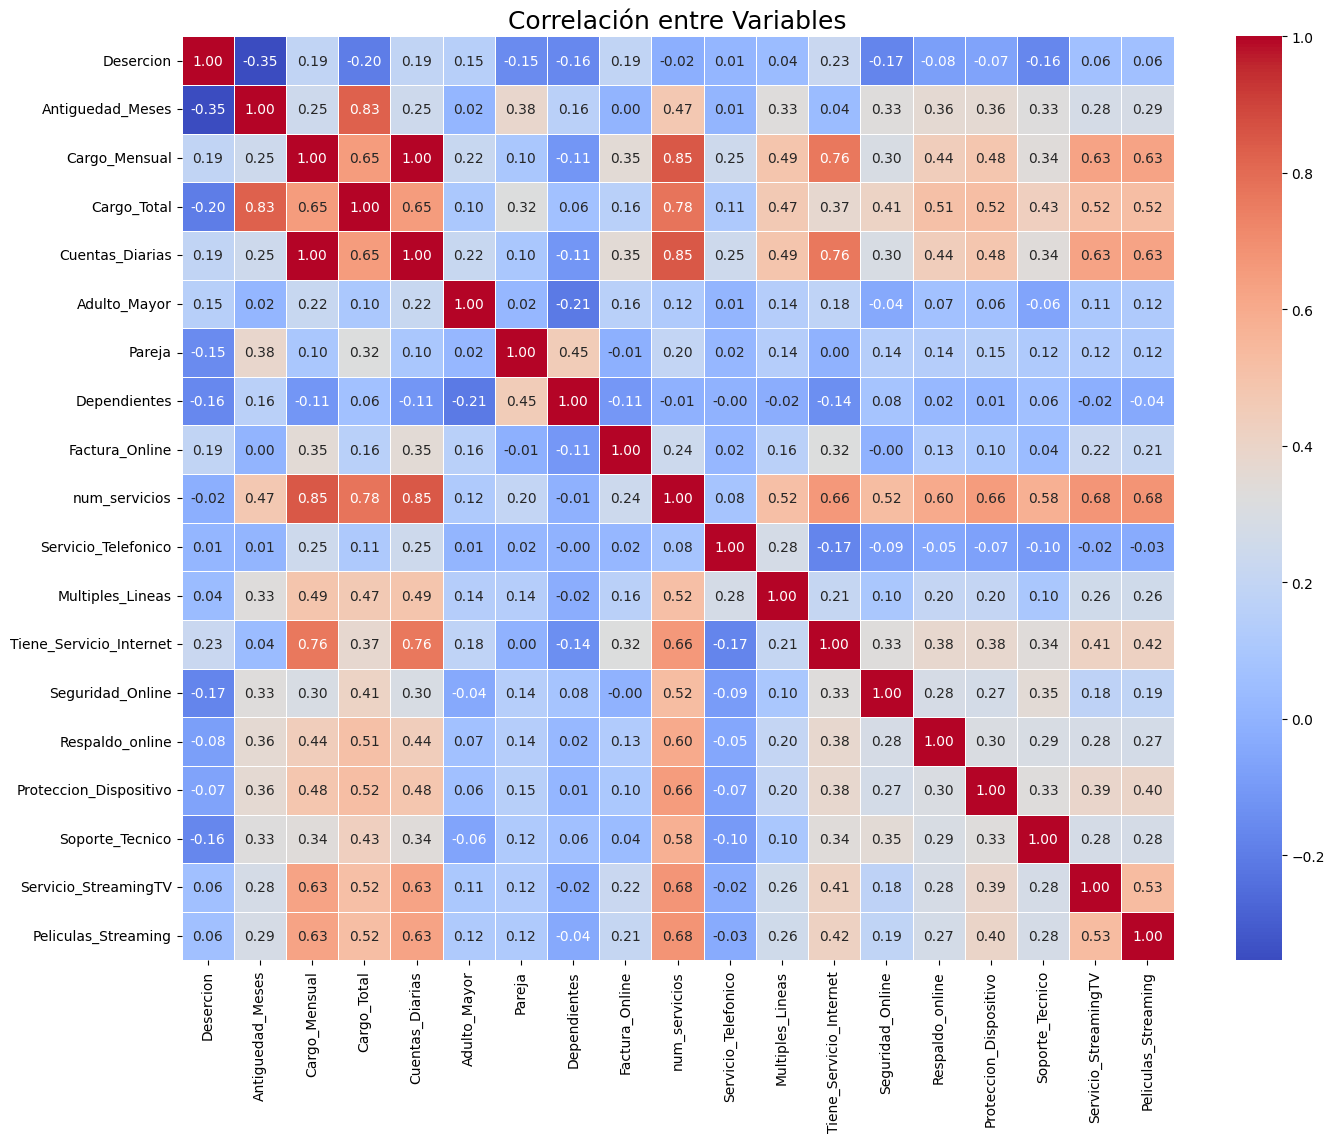

In [249]:
# Crear la columna 'num_servicios' sumando los servicios binarios
servicios_binarios = [
    'Servicio_Telefonico',
    'Multiples_Lineas',
    'Tiene_Servicio_Internet',
    'Seguridad_Online',
    'Respaldo_online',
    'Proteccion_Dispositivo',
    'Soporte_Tecnico',
    'Servicio_StreamingTV',
    'Peliculas_Streaming'
]
df['num_servicios'] = df[servicios_binarios].sum(axis=1)

# Seleccionar las columnas numéricas relevantes, incluyendo 'Desercion', 'Cuentas_Diarias' y 'num_servicios'
columnas_para_correlacion = [
    'Desercion',
    'Antiguedad_Meses',
    'Cargo_Mensual',
    'Cargo_Total',
    'Cuentas_Diarias',
    'Adulto_Mayor',
    'Pareja',
    'Dependientes',
    'Factura_Online',
    'num_servicios'
]
# También se pueden incluir los servicios binarios individualmente si se desea una granularidad mayor
columnas_para_correlacion.extend(servicios_binarios)

df_correlacion = df[columnas_para_correlacion].copy()

# Calcular la matriz de correlación
matriz_correlacion = df_correlacion.corr()

# Crear el heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlación entre Variables', fontsize=18)
plt.show()

## 4. Informe final

### Introducción

El objetivo de este análisis fue identificar los factores asociados a la evasión de clientes (Churn) en Telecom X, entendida como la cancelación del servicio por parte de los usuarios. Este problema impacta directamente los ingresos, incrementa los costos de adquisición de nuevos clientes y reduce la estabilidad del negocio. A partir de los datos históricos de clientes, se realizó un proceso de preparación y análisis para detectar patrones de deserción y proponer acciones de retención.

### Limpieza y Tratamiento de Datos

Durante la preparación de los datos se realizaron las siguientes tareas:

- Carga de datos desde una fuente JSON y normalización de la estructura.
- Revisión de tipos de datos, valores únicos, duplicados, nulos y valores en blanco.
- Conversión de columnas numéricas, en especial `Cargo_Total`, para asegurar análisis válidos.
- Eliminación de registros con `Churn` vacío y manejo de valores faltantes en variables clave.
- Renombrado de columnas a nombres claros en español para facilitar el análisis.
- Creación de nuevas variables derivadas como `Cuentas_Diarias`, `Antiguedad_Categoria`, `Cargo_Total_Categoria`, `Tiene_Servicio_Internet` y `num_servicios`.
- Estandarización de variables categóricas y binarias (por ejemplo, mapeo de `Yes/No` a 1/0).

Este proceso aseguró consistencia y calidad en los datos para las etapas de visualización e interpretación.

### Análisis Exploratorio de Datos

Se realizaron visualizaciones y análisis descriptivos para entender el comportamiento de la deserción:

- **Distribución general de deserción**: permitió observar la proporción de clientes que desertan frente a los que permanecen.
- **Deserción por antigüedad**: se evidenció mayor riesgo de deserción en los primeros meses, especialmente en el primer año.
- **Deserción por tipo de contrato**: el contrato mensual mostró mayor concentración de clientes que desertan frente a contratos de mayor duración.
- **Deserción por tipo de servicio de internet**: se observaron diferencias de evasión entre categorías de servicio.
- **Deserción por método de pago**: el cheque electrónico aparece como el método asociado a mayor deserción.
- **Relación entre servicios contratados y churn (gráfico radar)**: mostró diferencias entre clientes que desertan y no desertan en la adopción de servicios adicionales.
- **Relación entre gasto y deserción**: el análisis por categorías de `Cargo_Total` ayudó a identificar segmentos de mayor vulnerabilidad.
- **Mapa de correlación**: permitió detectar relaciones entre deserción y variables como antigüedad, cargos y número de servicios.

### Conclusiones e Insights

Con base en el análisis, los principales hallazgos fueron:

- La deserción se concentra con mayor fuerza en clientes de baja antigüedad.
- Los contratos mensuales presentan mayor riesgo de churn que los contratos anuales o de dos años.
- El método de pago por cheque electrónico se asocia con mayor deserción.
- Existen patrones de comportamiento por tipo de servicio que diferencian a clientes que desertan de los que permanecen.
- Variables de permanencia (antigüedad), gasto y cantidad de servicios tienen relación con la probabilidad de evasión.

En conjunto, estos hallazgos permiten segmentar mejor a los clientes y priorizar estrategias de retención en los grupos más propensos a abandonar.

### Recomendaciones

A partir de los resultados, se proponen las siguientes acciones estratégicas:

- Implementar campañas de retención temprana para clientes nuevos (primeros 12 meses).
- Incentivar la migración de contratos mensuales a planes de mayor permanencia (descuentos, beneficios exclusivos o paquetes de valor).
- Diseñar acciones específicas para clientes con método de pago por cheque electrónico (promover débito automático o tarjeta con incentivos).
- Fortalecer ofertas de valor en servicios complementarios para aumentar vinculación y reducir intención de baja.
- Construir un modelo predictivo de churn como siguiente fase del proyecto para identificar riesgo individual y activar acciones preventivas.
- Monitorear periódicamente KPIs de retención por segmento (antigüedad, contrato, método de pago y servicios) para evaluar impacto de las estrategias.

### Cierre

El análisis permitió transformar datos operativos en decisiones accionables para reducir la evasión. Las visualizaciones respaldan que la retención debe enfocarse en clientes nuevos, contratos de baja permanencia y segmentos con señales tempranas de riesgo. Con una estrategia proactiva basada en datos, Telecom X puede mejorar su tasa de permanencia y la rentabilidad de su base de clientes.